In [23]:
# =========================================
# 1. Imports
# =========================================
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import argparse
import os
import sys


In [2]:
# =========================================
# 2. CSV-Datei einlesen
# =========================================


df = pd.read_csv("../data/processed/selects_2023_clean.csv")

df.shape
df.head()

C:\Users\baber\AppData\Local\Temp\ipykernel_30644\3745989852.py:6: DtypeWarning: Columns (206,207,208,209,210,211,212,213,214,215) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/selects_2023_clean.csv")


,userid,langint,imode,indate_paper,language_paper,intstart,intend,finished,completion_rate,totaltime,...,weight_tot,weight_t_zh,weight_p_zh,weight_tot_zh,weight_t_ti,weight_p_ti,weight_tot_ti,weight_t_ge,weight_p_ge,weight_tot_ge
0,1001,2,1,,,11/7/2023 14:28:40,11/16/2023 21:19:15,1,2,"13370,5666666667",...,",599246512333914",1,1,1,1,1,1,"1,49920369",1,"1,49920369"
1,1002,1,1,,,10/24/2023 13:26:04,10/24/2023 13:51:42,1,2,"25,6333333333333",...,",976448777640773",1,1,1,1,1,1,1,1,1
2,1003,1,1,,,11/13/2023 20:36:39,11/13/2023 20:56:14,1,2,"19,5666666666667",...,"1,18620046322414",1,1,1,1,1,1,1,1,1
3,1004,1,1,,,10/24/2023 7:41:41,10/24/2023 8:13:56,1,2,"32,2333333333333",...,",552334100995496",1,1,1,1,1,1,1,1,1
4,1005,1,1,,,11/3/2023 13:42:10,11/3/2023 14:05:17,1,2,"23,1166666666667",...,",188235121344307",1,1,1,1,1,1,1,1,1


In [11]:
df.columns

Index(['userid', 'langint', 'imode', 'indate_paper', 'language_paper',
       'intstart', 'intend', 'finished', 'completion_rate', 'totaltime',
       ...
       'weight_t_zh', 'weight_p_zh', 'weight_tot_zh', 'weight_t_ti',
       'weight_p_ti', 'weight_tot_ti', 'weight_t_ge', 'weight_p_ge',
       'weight_tot_ge', 'voted'],
      dtype='object', length=309)

In [6]:
df["f11100rec"].value_counts(dropna=False)

f11100rec
 1     3268
 0     1716
-99      47
-98       2
Name: count, dtype: int64

In [12]:
df["f11800main6"].value_counts(dropna=False)

f11800main6
       1717
40      769
30      619
21      525
10      520
350     293
50      233
60      200
-99      99
998       9
Name: count, dtype: int64

In [13]:
df["birthyear"].describe()

count    4984.000000
mean     1962.031902
std       138.420704
min       -99.000000
25%      1957.000000
50%      1969.000000
75%      1986.000000
max      2005.000000
Name: birthyear, dtype: float64

In [14]:
# remove missing turnout values
df = df[df["f11100rec"] >= 0]

In [15]:
def assign_generation(year):
    if pd.isna(year):
        return pd.NA
    elif year <= 1945:
        return "Silent Generation"
    elif 1946 <= year <= 1964:
        return "Baby Boomers"
    elif 1965 <= year <= 1980:
        return "Generation X"
    elif 1981 <= year <= 1996:
        return "Millennials"
    else:
        return "Generation Z"

In [16]:
df["generation"] = df["birthyear"].apply(assign_generation)

In [17]:
df["generation"].value_counts(dropna=False)

generation
Baby Boomers         1611
Generation X         1365
Millennials          1111
Generation Z          519
Silent Generation     378
Name: count, dtype: int64

In [19]:
df["voted"] = df["f11100rec"]
df["voted"].value_counts()

voted
1    3268
0    1716
Name: count, dtype: int64

In [20]:
turnout = df.groupby("generation")["voted"].mean() * 100
turnout

generation
Baby Boomers         75.356921
Generation X         66.007326
Generation Z         47.398844
Millennials          56.795680
Silent Generation    73.015873
Name: voted, dtype: float64

In [21]:
generation_order = [
    "Silent Generation",
    "Baby Boomers",
    "Generation X",
    "Millennials",
    "Generation Z"
]

turnout = turnout.reindex(generation_order)
turnout

generation
Silent Generation    73.015873
Baby Boomers         75.356921
Generation X         66.007326
Millennials          56.795680
Generation Z         47.398844
Name: voted, dtype: float64

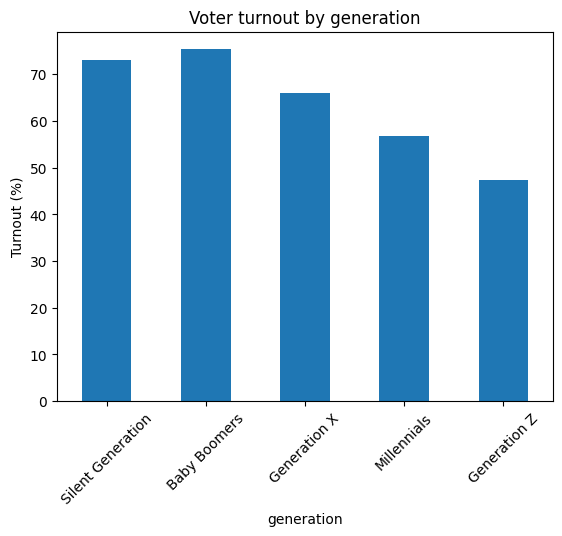

In [24]:
turnout.plot(kind="bar")
plt.ylabel("Turnout (%)")
plt.title("Voter turnout by generation")
plt.xticks(rotation=45)
plt.show()